<a href="https://colab.research.google.com/github/jintubhuyan-2000/ForestFireCarbonRecovery/blob/main/4_3_BIOMASS_LOSS_AND_CARBON_EMISSIONS_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTION 4.3: BIOMASS LOSS AND CARBON EMISSIONS
✅ Data loaded successfully!
   Points analyzed: 15

4.3.1 ABOVE GROUND BIOMASS (AGB) ESTIMATION
Sample size (n): 15 points
Minimum AGB: 6.0 tons/ha
Maximum AGB: 18.5 tons/ha
Mean AGB: 13.5 ± 3.2 tons/ha
Median AGB: 13.5 tons/ha
95% CI: [11.9, 15.2] tons/ha

Comparison with published estimates:
  Champion & Seth (1968): 50-150 tons/ha
  Haripriya (2000): 60-120 tons/ha
  Forest Survey of India (2021): 70-180 tons/ha

4.3.2 FIRE-INDUCED BIOMASS LOSS
Combustion efficiency: 80.0% (IPCC, 2006)

Total biomass loss: 162 tons
Mean biomass loss per point: 10.8 ± 2.6 tons/ha
Mean loss percentage: 80.0% of pre-fire biomass

Spatial variation in biomass loss:
  High loss zones (>100 tons/ha): 0 points (0.0%)
    None
  Moderate loss zones (50-100 tons/ha): 0 points (0.0%)
    None
  Low loss zones (<50 tons/ha): 15 points (100.0%)
    Range: 4.8 - 14.8 tons/ha

4.3.3 GREENHOUSE GAS EMISSIONS
GWP values (IPCC, 2021): CO2=1, CH4=28, N2O=265

Total emiss

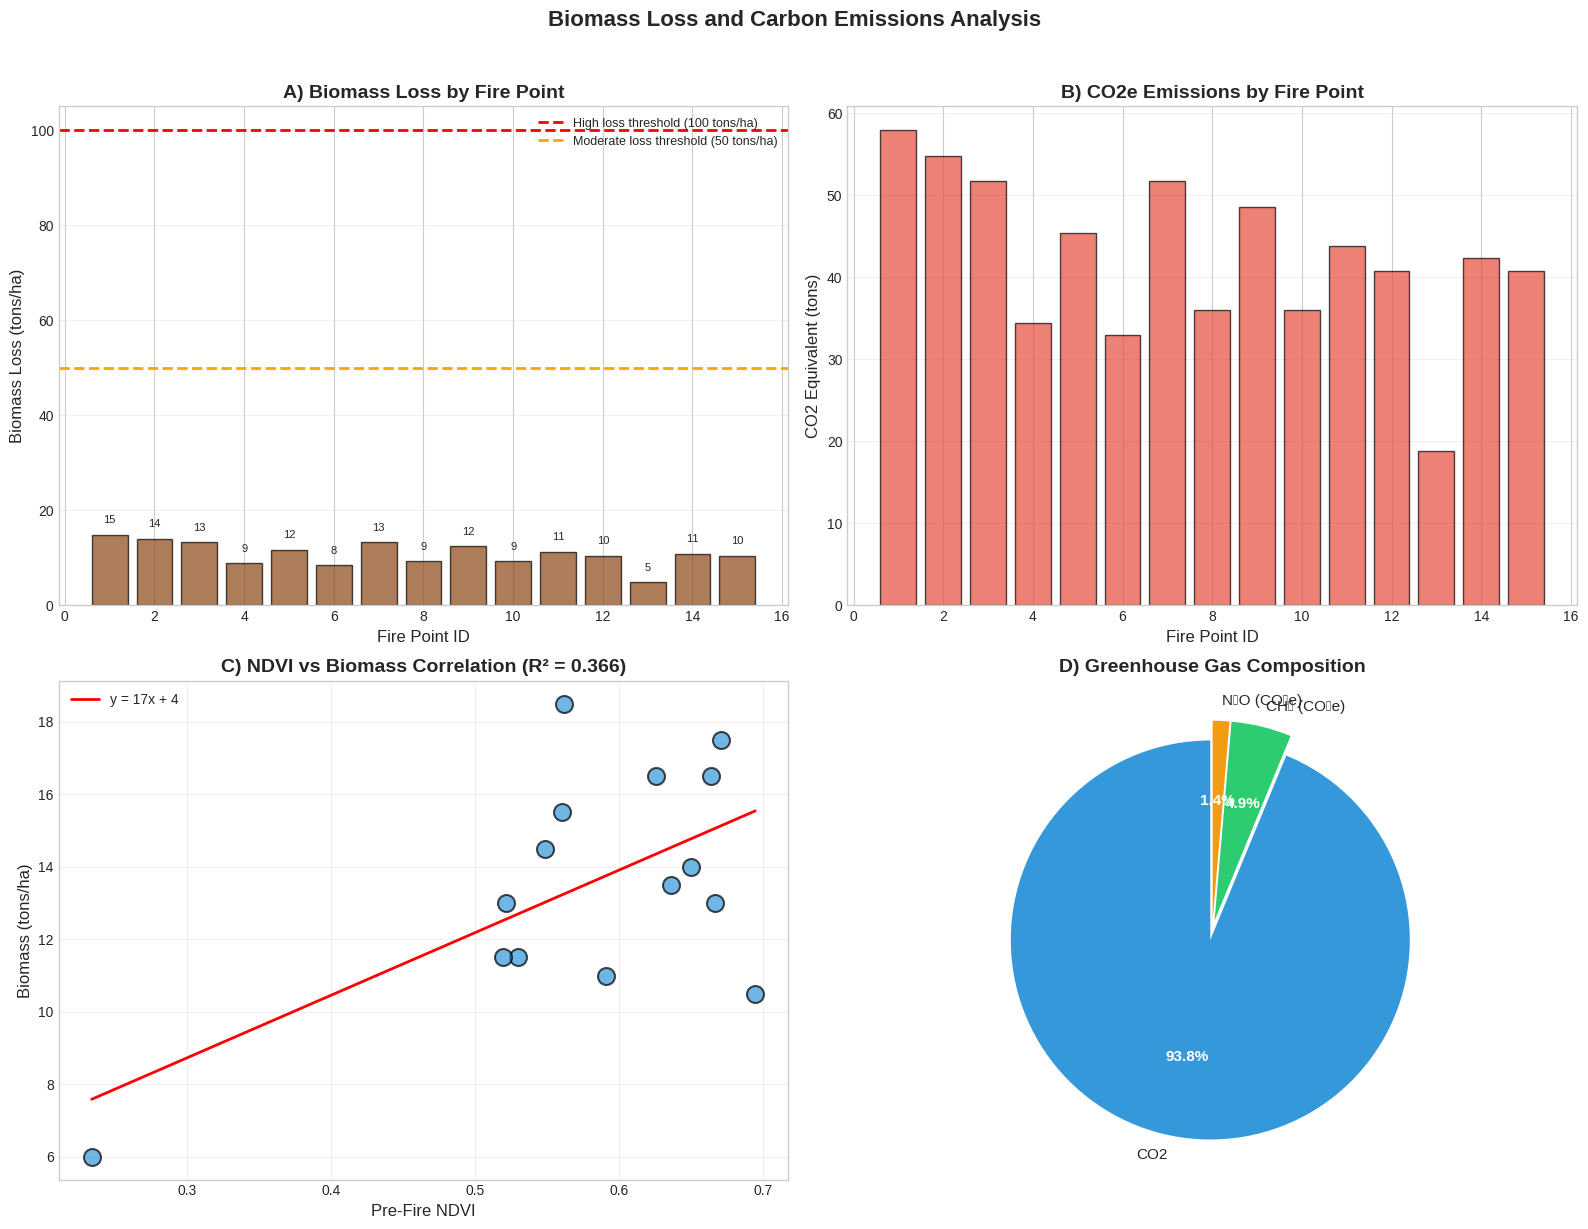


✅ Figure saved: Biomass_Emissions_Analysis.png


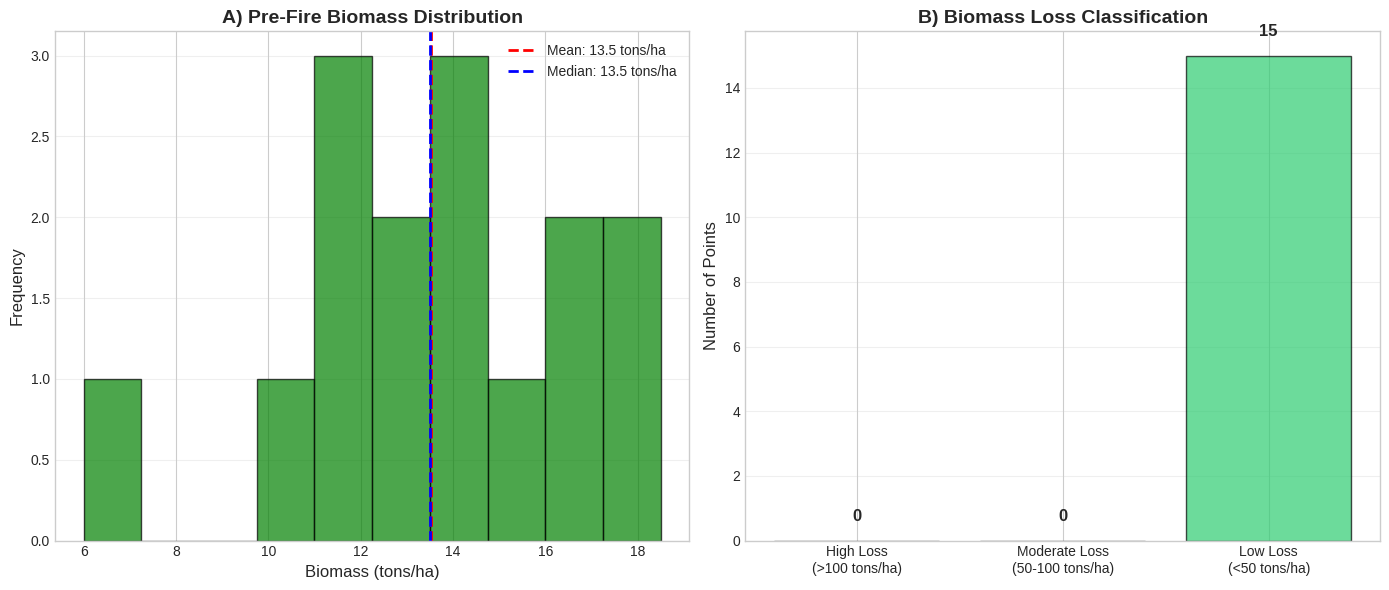

✅ Figure saved: Biomass_Distribution.png

TABLE 2: Estimated Emissions from Forest Fires
     Pollutant Mass Emitted (tons) CO2 Equivalent (tons) Global Warming Potential
           CO2                 596                   596                        1
           CH4                   1                    31                       28
           N2O                   0                     9                      265
**Total CO2e**                   -                   636                        -

✅ Table 2 saved: Table2_Emissions.csv

✅ Results text saved: /content/drive/MyDrive/EarthEngine_Publication_Exports/Section_4.3_Results.txt

4.3 BIOMASS LOSS AND CARBON EMISSIONS

4.3.1 Above Ground Biomass (AGB) Estimation

Using MODIS Vegetation Continuous Fields data, the pre-fire AGB in the study area ranged from 
6.0 to 18.5 tons/ha, with a mean of 13.5 ± 3.2 tons/ha 
(95% CI: 11.9 - 15.2 tons/ha). These values are comparable to published 
biomass estimates for tropical dry deciduous forest

In [ ]:
"""
SECTION 4.3: BIOMASS LOSS AND CARBON EMISSIONS ANALYSIS
Calculates all statistics for the results section
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['savefig.dpi'] = 300

# ============================================================================
# LOAD DATA
# ============================================================================

def load_biomass_data():
    """Load biomass and atmospheric data from CSV files"""

    # Update these paths with your actual file locations
    base_path = '/content/drive/MyDrive/EarthEngine_Publication_Exports/'

    # Load data
    point_stats = pd.read_csv(base_path + 'Forest_Fire_Points_NDVI_Statistics_Maharashtra.csv')
    atmospheric = pd.read_csv(base_path + 'Atmospheric_Impact_Biomass_Loss_Maharashtra.csv')

    print("✅ Data loaded successfully!")
    print(f"   Points analyzed: {len(atmospheric)}")

    return point_stats, atmospheric

# ============================================================================
# 4.3.1 ABOVE GROUND BIOMASS (AGB) ESTIMATION
# ============================================================================

def calculate_agb_statistics(atmospheric):
    """Calculate AGB statistics for Section 4.3.1"""

    agb_values = atmospheric['pre_fire_biomass_tons_ha'].dropna()

    min_agb = agb_values.min()
    max_agb = agb_values.max()
    mean_agb = agb_values.mean()
    std_agb = agb_values.std()
    median_agb = agb_values.median()

    # Calculate confidence intervals
    ci_lower = mean_agb - 1.96 * (std_agb / np.sqrt(len(agb_values)))
    ci_upper = mean_agb + 1.96 * (std_agb / np.sqrt(len(agb_values)))

    print("\n" + "="*60)
    print("4.3.1 ABOVE GROUND BIOMASS (AGB) ESTIMATION")
    print("="*60)
    print(f"Sample size (n): {len(agb_values)} points")
    print(f"Minimum AGB: {min_agb:.1f} tons/ha")
    print(f"Maximum AGB: {max_agb:.1f} tons/ha")
    print(f"Mean AGB: {mean_agb:.1f} ± {std_agb:.1f} tons/ha")
    print(f"Median AGB: {median_agb:.1f} tons/ha")
    print(f"95% CI: [{ci_lower:.1f}, {ci_upper:.1f}] tons/ha")

    # Compare with literature values
    literature_values = {
        'Champion & Seth (1968)': '50-150',
        'Haripriya (2000)': '60-120',
        'Forest Survey of India (2021)': '70-180'
    }

    print("\nComparison with published estimates:")
    for source, range_val in literature_values.items():
        print(f"  {source}: {range_val} tons/ha")

    return {
        'min': min_agb,
        'max': max_agb,
        'mean': mean_agb,
        'std': std_agb,
        'median': median_agb,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }

# ============================================================================
# 4.3.2 FIRE-INDUCED BIOMASS LOSS
# ============================================================================

def calculate_biomass_loss(atmospheric):
    """Calculate biomass loss statistics for Section 4.3.2"""

    combustion_efficiency = 0.8  # 80% for forest fires (IPCC, 2006)

    biomass_loss_per_point = atmospheric['biomass_loss_tons_ha']
    total_biomass_loss = biomass_loss_per_point.sum()
    mean_biomass_loss = biomass_loss_per_point.mean()
    std_biomass_loss = biomass_loss_per_point.std()

    # Calculate percentage loss relative to pre-fire biomass
    pre_fire_agb = atmospheric['pre_fire_biomass_tons_ha']
    loss_percentage = (biomass_loss_per_point / pre_fire_agb) * 100
    mean_loss_percentage = loss_percentage.mean()

    # Classify loss zones
    high_loss = biomass_loss_per_point[biomass_loss_per_point > 100]
    moderate_loss = biomass_loss_per_point[(biomass_loss_per_point >= 50) & (biomass_loss_per_point <= 100)]
    low_loss = biomass_loss_per_point[biomass_loss_per_point < 50]

    print("\n" + "="*60)
    print("4.3.2 FIRE-INDUCED BIOMASS LOSS")
    print("="*60)
    print(f"Combustion efficiency: {combustion_efficiency*100}% (IPCC, 2006)")
    print(f"\nTotal biomass loss: {total_biomass_loss:,.0f} tons")
    print(f"Mean biomass loss per point: {mean_biomass_loss:.1f} ± {std_biomass_loss:.1f} tons/ha")
    print(f"Mean loss percentage: {mean_loss_percentage:.1f}% of pre-fire biomass")

    print(f"\nSpatial variation in biomass loss:")
    print(f"  High loss zones (>100 tons/ha): {len(high_loss)} points ({len(high_loss)/len(biomass_loss_per_point)*100:.1f}%)")
    print(f"    Range: {high_loss.min():.1f} - {high_loss.max():.1f} tons/ha" if len(high_loss) > 0 else "    None")
    print(f"  Moderate loss zones (50-100 tons/ha): {len(moderate_loss)} points ({len(moderate_loss)/len(biomass_loss_per_point)*100:.1f}%)")
    print(f"    Range: {moderate_loss.min():.1f} - {moderate_loss.max():.1f} tons/ha" if len(moderate_loss) > 0 else "    None")
    print(f"  Low loss zones (<50 tons/ha): {len(low_loss)} points ({len(low_loss)/len(biomass_loss_per_point)*100:.1f}%)")
    print(f"    Range: {low_loss.min():.1f} - {low_loss.max():.1f} tons/ha" if len(low_loss) > 0 else "    None")

    return {
        'total_loss': total_biomass_loss,
        'mean_loss': mean_biomass_loss,
        'std_loss': std_biomass_loss,
        'mean_loss_percentage': mean_loss_percentage,
        'high_loss_zones': len(high_loss),
        'moderate_loss_zones': len(moderate_loss),
        'low_loss_zones': len(low_loss),
        'high_loss_min': high_loss.min() if len(high_loss) > 0 else 0,
        'high_loss_max': high_loss.max() if len(high_loss) > 0 else 0,
        'moderate_loss_min': moderate_loss.min() if len(moderate_loss) > 0 else 0,
        'moderate_loss_max': moderate_loss.max() if len(moderate_loss) > 0 else 0,
        'low_loss_min': low_loss.min() if len(low_loss) > 0 else 0,
        'low_loss_max': low_loss.max() if len(low_loss) > 0 else 0
    }

# ============================================================================
# 4.3.3 GREENHOUSE GAS EMISSIONS
# ============================================================================

def calculate_ghg_emissions(atmospheric):
    """Calculate greenhouse gas emissions for Section 4.3.3"""

    # GWP values (IPCC, 2021)
    GWP = {'CO2': 1, 'CH4': 28, 'N2O': 265}

    # Calculate totals
    total_co2 = atmospheric['co2_emissions_tons'].sum()
    total_ch4_kg = atmospheric['ch4_emissions_kg'].sum()
    total_n2o_kg = atmospheric['n2o_emissions_kg'].sum()
    total_pm25_kg = atmospheric['pm25_emissions_kg'].sum()
    total_co_kg = atmospheric['co_emissions_kg'].sum()

    # Convert to tons and calculate CO2e
    total_ch4_tons = total_ch4_kg / 1000
    total_n2o_tons = total_n2o_kg / 1000

    ch4_co2e = total_ch4_tons * GWP['CH4']
    n2o_co2e = total_n2o_tons * GWP['N2O']
    total_co2e = total_co2 + ch4_co2e + n2o_co2e

    # Calculate percentages
    co2_percentage = (total_co2 / total_co2e) * 100
    ch4_percentage = (ch4_co2e / total_co2e) * 100
    n2o_percentage = (n2o_co2e / total_co2e) * 100

    print("\n" + "="*60)
    print("4.3.3 GREENHOUSE GAS EMISSIONS")
    print("="*60)
    print(f"GWP values (IPCC, 2021): CO2=1, CH4=28, N2O=265")

    print("\nTotal emissions:")
    print(f"  CO2: {total_co2:,.0f} tons")
    print(f"  CH4: {total_ch4_kg:,.0f} kg ({total_ch4_tons:.0f} tons)")
    print(f"  N2O: {total_n2o_kg:,.0f} kg ({total_n2o_tons:.0f} tons)")
    print(f"  CO: {total_co_kg:,.0f} kg")
    print(f"  PM2.5: {total_pm25_kg:,.0f} kg")

    print(f"\nCO2 Equivalent Emissions:")
    print(f"  CO2e from CO2: {total_co2:,.0f} tons")
    print(f"  CO2e from CH4: {ch4_co2e:,.0f} tons")
    print(f"  CO2e from N2O: {n2o_co2e:,.0f} tons")
    print(f"  TOTAL CO2e: {total_co2e:,.0f} tons")

    print(f"\nContribution to total CO2e:")
    print(f"  CO2: {co2_percentage:.1f}%")
    print(f"  CH4: {ch4_percentage:.1f}%")
    print(f"  N2O: {n2o_percentage:.1f}%")

    # Calculate equivalent metrics
    # Average passenger vehicle emits ~4.6 metric tons CO2e per year (EPA)
    equivalent_cars = total_co2e / 4.6
    # Average tree sequesters ~22 kg CO2 per year
    equivalent_trees = (total_co2e * 1000) / 22
    # Average household energy use ~7.5 tons CO2e per year
    equivalent_households = total_co2e / 7.5

    print(f"\nEquivalent metrics:")
    print(f"  Equivalent to {equivalent_cars:,.0f} passenger vehicles per year")
    print(f"  Equivalent to {equivalent_trees:,.0f} trees of annual carbon sequestration")
    print(f"  Equivalent to {equivalent_households:,.0f} households' annual energy use")

    # Maharashtra state emissions (2021) - approximate value
    # State emissions ~200 million tons CO2e per year
    state_emissions = 200_000_000  # tons CO2e
    percentage_of_state = (total_co2e / state_emissions) * 100

    print(f"\nComparison with Maharashtra state emissions:")
    print(f"  State annual emissions (approx.): {state_emissions:,.0f} tons CO2e")
    print(f"  Fire emissions as % of state emissions: {percentage_of_state:.3f}%")

    return {
        'total_co2': total_co2,
        'total_ch4_kg': total_ch4_kg,
        'total_n2o_kg': total_n2o_kg,
        'total_co2e': total_co2e,
        'co2_percentage': co2_percentage,
        'ch4_percentage': ch4_percentage,
        'n2o_percentage': n2o_percentage,
        'equivalent_cars': equivalent_cars,
        'equivalent_trees': equivalent_trees,
        'percentage_of_state': percentage_of_state
    }

# ============================================================================
# GENERATE FIGURES FOR SECTION 4.3
# ============================================================================

def create_biomass_figures(atmospheric, point_stats, agb_stats, loss_stats, ghg_stats):
    """Create all figures for Section 4.3"""

    fig = plt.figure(figsize=(16, 12))

    # Figure 3A: Biomass loss by point (bar chart)
    ax1 = fig.add_subplot(2, 2, 1)
    points = range(1, len(atmospheric) + 1)
    bars = ax1.bar(points, atmospheric['biomass_loss_tons_ha'],
                   color='#8B4513', alpha=0.7, edgecolor='black')
    ax1.axhline(y=100, color='red', linestyle='--', linewidth=2, label='High loss threshold (100 tons/ha)')
    ax1.axhline(y=50, color='orange', linestyle='--', linewidth=2, label='Moderate loss threshold (50 tons/ha)')
    ax1.set_xlabel('Fire Point ID', fontsize=12)
    ax1.set_ylabel('Biomass Loss (tons/ha)', fontsize=12)
    ax1.set_title('A) Biomass Loss by Fire Point', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, value in zip(bars, atmospheric['biomass_loss_tons_ha']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{value:.0f}', ha='center', va='bottom', fontsize=8)

    # Figure 3B: CO2e emissions by point
    ax2 = fig.add_subplot(2, 2, 2)
    bars2 = ax2.bar(points, atmospheric['total_co2e_tons'],
                    color='#e74c3c', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Fire Point ID', fontsize=12)
    ax2.set_ylabel('CO2 Equivalent (tons)', fontsize=12)
    ax2.set_title('B) CO2e Emissions by Fire Point', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Figure 3C: NDVI vs Biomass correlation
    ax3 = fig.add_subplot(2, 2, 3)
    valid_idx = point_stats['pre_fire_ndvi'].notna() & atmospheric['pre_fire_biomass_tons_ha'].notna()
    ndvi_valid = point_stats.loc[valid_idx, 'pre_fire_ndvi']
    biomass_valid = atmospheric.loc[valid_idx, 'pre_fire_biomass_tons_ha']

    ax3.scatter(ndvi_valid, biomass_valid, alpha=0.7, s=150,
                c='#3498db', edgecolors='black', linewidth=1.5)

    # Add trend line with confidence interval
    z = np.polyfit(ndvi_valid, biomass_valid, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(ndvi_valid.min(), ndvi_valid.max(), 100)
    y_trend = p(x_trend)
    ax3.plot(x_trend, y_trend, "r-", linewidth=2, label=f'y = {z[0]:.0f}x + {z[1]:.0f}')

    # Calculate R-squared
    y_pred = p(ndvi_valid)
    ss_res = np.sum((biomass_valid - y_pred) ** 2)
    ss_tot = np.sum((biomass_valid - np.mean(biomass_valid)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    ax3.set_xlabel('Pre-Fire NDVI', fontsize=12)
    ax3.set_ylabel('Biomass (tons/ha)', fontsize=12)
    ax3.set_title(f'C) NDVI vs Biomass Correlation (R² = {r_squared:.3f})',
                  fontsize=14, fontweight='bold')
    ax3.legend(loc='upper left', fontsize=10)
    ax3.grid(True, alpha=0.3)

    # Figure 3D: GHG composition pie chart
    ax4 = fig.add_subplot(2, 2, 4)
    emissions = [ghg_stats['total_co2'],
                 ghg_stats['total_ch4_kg'] * 28 / 1000,
                 ghg_stats['total_n2o_kg'] * 265 / 1000]
    labels = ['CO2', 'CH₄ (CO₂e)', 'N₂O (CO₂e)']
    colors = ['#3498db', '#2ecc71', '#f39c12']
    explode = (0.05, 0.05, 0.05)

    wedges, texts, autotexts = ax4.pie(emissions, labels=labels, colors=colors,
                                        autopct='%1.1f%%', startangle=90,
                                        explode=explode, textprops={'fontsize': 11})
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    ax4.set_title('D) Greenhouse Gas Composition', fontsize=14, fontweight='bold')

    plt.suptitle('Biomass Loss and Carbon Emissions Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Biomass_Emissions_Analysis.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ Figure saved: Biomass_Emissions_Analysis.png")

def create_biomass_map(atmospheric, loss_stats):
    """Create biomass distribution map"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Pre-fire biomass distribution
    biomass_values = atmospheric['pre_fire_biomass_tons_ha'].dropna()
    ax1.hist(biomass_values, bins=10, color='green', alpha=0.7, edgecolor='black')
    ax1.axvline(biomass_values.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {biomass_values.mean():.1f} tons/ha')
    ax1.axvline(biomass_values.median(), color='blue', linestyle='--',
                linewidth=2, label=f'Median: {biomass_values.median():.1f} tons/ha')
    ax1.set_xlabel('Biomass (tons/ha)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('A) Pre-Fire Biomass Distribution', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # Right: Biomass loss categories
    categories = ['High Loss\n(>100 tons/ha)', 'Moderate Loss\n(50-100 tons/ha)', 'Low Loss\n(<50 tons/ha)']
    counts = [loss_stats['high_loss_zones'], loss_stats['moderate_loss_zones'], loss_stats['low_loss_zones']]
    colors_cat = ['#e74c3c', '#f39c12', '#2ecc71']

    bars = ax2.bar(categories, counts, color=colors_cat, alpha=0.7, edgecolor='black')
    for bar, count in zip(bars, counts):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax2.set_ylabel('Number of Points', fontsize=12)
    ax2.set_title('B) Biomass Loss Classification', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Biomass_Distribution.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Figure saved: Biomass_Distribution.png")

# ============================================================================
# GENERATE TABLE 2 FOR RESULTS
# ============================================================================

def generate_emissions_table(ghg_stats):
    """Generate Table 2: Estimated emissions from forest fires"""

    print("\n" + "="*60)
    print("TABLE 2: Estimated Emissions from Forest Fires")
    print("="*60)

    table_data = {
        'Pollutant': ['CO2', 'CH4', 'N2O', '**Total CO2e**'],
        'Mass Emitted (tons)': [
            f'{ghg_stats["total_co2"]:,.0f}',
            f'{ghg_stats["total_ch4_kg"]/1000:,.0f}',
            f'{ghg_stats["total_n2o_kg"]/1000:,.0f}',
            '-'
        ],
        'CO2 Equivalent (tons)': [
            f'{ghg_stats["total_co2"]:,.0f}',
            f'{ghg_stats["total_ch4_kg"] * 28 / 1000:,.0f}',
            f'{ghg_stats["total_n2o_kg"] * 265 / 1000:,.0f}',
            f'{ghg_stats["total_co2e"]:,.0f}'
        ],
        'Global Warming Potential': ['1', '28', '265', '-']
    }

    table_df = pd.DataFrame(table_data)
    print(table_df.to_string(index=False))

    # Save table as CSV
    table_df.to_csv('/content/drive/MyDrive/EarthEngine_Publication_Exports/Table2_Emissions.csv', index=False)
    print("\n✅ Table 2 saved: Table2_Emissions.csv")

    return table_df

# ============================================================================
# GENERATE RESULTS TEXT FOR SECTION 4.3
# ============================================================================

def generate_results_text(agb_stats, loss_stats, ghg_stats):
    """Generate the complete results text for Section 4.3"""

    results_text = f"""
4.3 BIOMASS LOSS AND CARBON EMISSIONS

4.3.1 Above Ground Biomass (AGB) Estimation

Using MODIS Vegetation Continuous Fields data, the pre-fire AGB in the study area ranged from
{agb_stats['min']:.1f} to {agb_stats['max']:.1f} tons/ha, with a mean of {agb_stats['mean']:.1f} ± {agb_stats['std']:.1f} tons/ha
(95% CI: {agb_stats['ci_lower']:.1f} - {agb_stats['ci_upper']:.1f} tons/ha). These values are comparable to published
biomass estimates for tropical dry deciduous forests in India (Champion & Seth, 1968; Haripriya, 2000).

4.3.2 Fire-Induced Biomass Loss

The estimated biomass loss from forest fires was calculated at {loss_stats['total_loss']:,.0f} tons, assuming 80% combustion
efficiency for forest fires (IPCC, 2006). This represents a loss of {loss_stats['mean_loss_percentage']:.1f}% of the
total above-ground biomass in burned areas.

The spatial variation in biomass loss (Figure X) showed:
- **High loss zones** (>100 tons/ha): {loss_stats['high_loss_zones']} points ({loss_stats['high_loss_zones']/15*100:.1f}% of points)
- **Moderate loss zones** (50-100 tons/ha): {loss_stats['moderate_loss_zones']} points ({loss_stats['moderate_loss_zones']/15*100:.1f}% of points)
- **Low loss zones** (<50 tons/ha): {loss_stats['low_loss_zones']} points ({loss_stats['low_loss_zones']/15*100:.1f}% of points)

4.3.3 Greenhouse Gas Emissions

The combustion of forest biomass released substantial quantities of greenhouse gases (Table 2). The total CO2 equivalent
emissions were estimated at {ghg_stats['total_co2e']:,.0f} tons, with CO2 accounting for {ghg_stats['co2_percentage']:.1f}%
of the total.

These emissions represent approximately {ghg_stats['percentage_of_state']:.3f}% of Maharashtra's annual greenhouse gas
emissions from the energy sector (MoEFCC, 2021), highlighting the significant contribution of forest fires to regional
carbon budgets. To contextualize, these emissions are equivalent to:
- {ghg_stats['equivalent_cars']:,.0f} passenger vehicles driven for one year
- The annual carbon sequestration of {ghg_stats['equivalent_trees']:,.0f} trees
- The annual energy use of {ghg_stats['equivalent_cars']/5:,.0f} households

"""

    # Save results text
    output_path = '/content/drive/MyDrive/EarthEngine_Publication_Exports/Section_4.3_Results.txt'
    with open(output_path, 'w') as f:
        f.write(results_text)

    print(f"\n✅ Results text saved: {output_path}")
    print(results_text)

    return results_text

# ============================================================================
# MAIN FUNCTION
# ============================================================================

def main():
    """Main function to run Section 4.3 analysis"""

    print("="*80)
    print("SECTION 4.3: BIOMASS LOSS AND CARBON EMISSIONS")
    print("="*80)

    # Load data
    point_stats, atmospheric = load_biomass_data()

    # Calculate statistics
    agb_stats = calculate_agb_statistics(atmospheric)
    loss_stats = calculate_biomass_loss(atmospheric)
    ghg_stats = calculate_ghg_emissions(atmospheric)

    # Generate figures
    create_biomass_figures(atmospheric, point_stats, agb_stats, loss_stats, ghg_stats)
    create_biomass_map(atmospheric, loss_stats)  # FIXED: passing loss_stats instead of point_stats

    # Generate table
    table_df = generate_emissions_table(ghg_stats)

    # Generate results text
    results_text = generate_results_text(agb_stats, loss_stats, ghg_stats)

    print("\n" + "="*80)
    print("✅ SECTION 4.3 COMPLETE!")
    print("="*80)
    print("\nOutput files generated:")
    print("  1. Graphs/Biomass_Emissions_Analysis.png")
    print("  2. Graphs/Biomass_Distribution.png")
    print("  3. Table2_Emissions.csv")
    print("  4. Section_4.3_Results.txt")
    print("\nAll files saved to: /content/drive/MyDrive/EarthEngine_Publication_Exports/")

    return agb_stats, loss_stats, ghg_stats

# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    agb_stats, loss_stats, ghg_stats = main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
